# Generation model test

In [2]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ast

In [3]:
with open("generation_model_summary.csv", 'r', encoding='utf-8') as f:
    lines = f.readlines()

fixed_lines = [lines[0]]
for line in lines[1:]:  # Skip header (index 0), iterate over data rows
    if line.startswith('"') and '"\n' in line:
        line = line[1:-2] + '\n'
        line = line.replace('""', '"')
    fixed_lines.append(line)

df = pd.read_csv(io.StringIO(''.join(fixed_lines)))

print(df.head())
print(df.dtypes)

   iteration generation_model  num_input_genes  num_output_genes  \
0          1               o3              250                74   
1          2               o3              250                69   
2          3               o3              250                73   
3          4               o3              250                78   
4          5               o3              250                76   

                                        output_genes  matched_genes  \
0  ['plxnb1', 'htra1', 'cldn19', 'srgap1', 'tnik'...             74   
1  ['plxnb1', 'cldn19', 'srgap1', 'tnik', 'efna5'...             69   
2  ['plxnb1', 'ccn3', 'sipa1l1', 'cldn19', 'srgap...             73   
3  ['htra1', 'cxcl14', 'emilin1', 'cxcl12', 'dpys...             78   
4  ['ifnar1', 'plxnb1', 'htra1', 'cers6', 'cldn19...             76   

                                 matched_genes_names  num_hallucinated_genes  \
0  ['plxnb1', 'htra1', 'cldn19', 'srgap1', 'tnik'...                       0   
1  [

### Halluciniation percentage per model

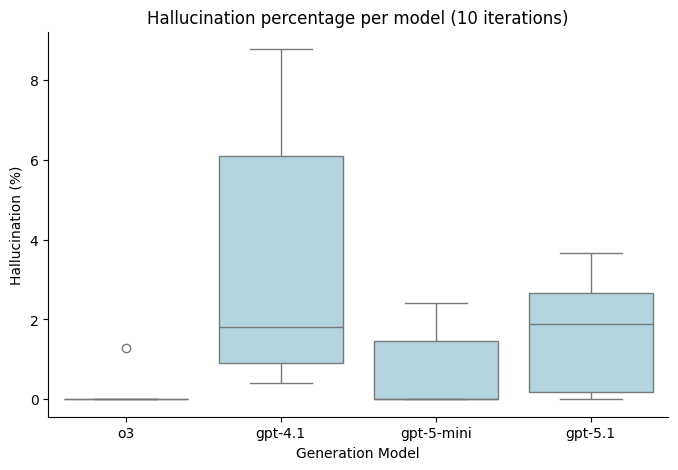

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="generation_model",
    y="hallucination_perc_generation",
    data=df,
    color="lightblue", 
    showfliers=True  
)

plt.title("Hallucination percentage per model (10 iterations)")
plt.xlabel("Generation Model")
plt.ylabel("Hallucination (%)")
sns.despine()
plt.show()


### Comparison of input, unique output and matched genes

In [5]:
df_grouped = (
    df
    .groupby("generation_model", as_index=False)
    .agg({
        "num_input_genes": "mean",
        "num_output_genes": "mean",
        "matched_genes": "mean"
    })
)

gene_data = df_grouped.melt(
    id_vars="generation_model",
    value_vars=["num_input_genes", "num_output_genes", "matched_genes"],
    var_name="Gene Type",
    value_name="Count"
)

fig = px.bar(
    gene_data,
    x="generation_model",
    y="Count",
    color="Gene Type",
    barmode="group",
    text="Count",
    hover_data={
        "generation_model": True,
        "Gene Type": True,
        "Count": True
    },
    labels={"generation_model":"Generation model", "Count":"Number of genes"},
    title="Comparison of input, unique output, and matched genes per model"
)

fig.update_layout(legend_title_text="Gene Type")
fig.show()


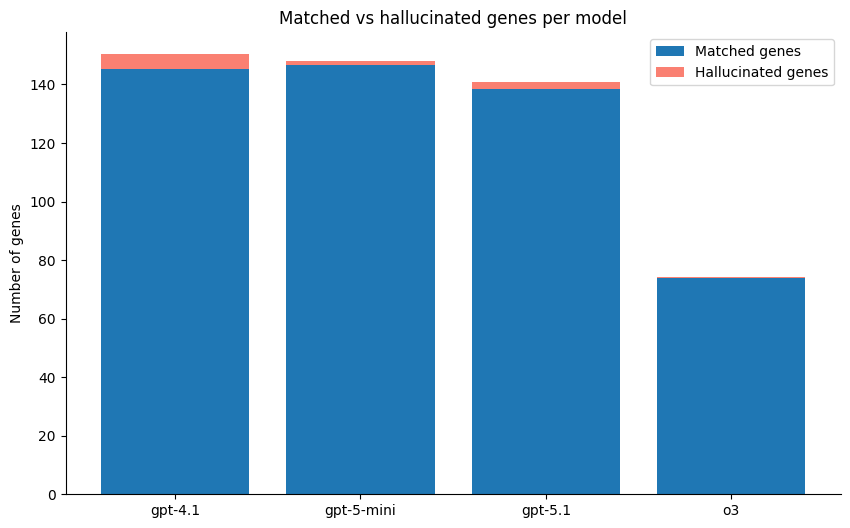

In [6]:
df_grouped["hallucinated_genes"] = df_grouped["num_output_genes"] - df_grouped["matched_genes"]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(df_grouped["generation_model"], df_grouped["matched_genes"], label="Matched genes")
ax.bar(df_grouped["generation_model"], df_grouped["hallucinated_genes"], 
       bottom=df_grouped["matched_genes"], label="Hallucinated genes", color="salmon")

ax.set_ylabel("Number of genes")
ax.set_title("Matched vs hallucinated genes per model")
ax.legend()
sns.despine()
plt.show()

In [7]:
# Zorg dat alles lijsten zijn
def ensure_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        import ast
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    return []

# Maak een dataframe met alle gehallucineerde genen per model per iteratie
records = []
for model in df["generation_model"].unique():
    for genes in df[df["generation_model"]==model]["hallucinated_genes_list"].apply(ensure_list):
        for gene in genes:
            records.append({"generation_model": model, "gene": gene})

halluc_df = pd.DataFrame(records)

# Tabel met tellingen van hoe vaak elk gen per model gehallucineerd is
gene_counts = halluc_df.groupby(["gene", "generation_model"]).size().unstack(fill_value=0)

# Sorteer op totale hallucinaties over alle modellen
gene_counts["total"] = gene_counts.sum(axis=1)
gene_counts = gene_counts.sort_values("total", ascending=False)
gene_counts = gene_counts.drop(columns="total")  # optioneel

display(gene_counts)



generation_model,gpt-4.1,gpt-5-mini,gpt-5.1,o3
gene,,,,
plp1,8,0,0,0
nrl,2,1,4,0
nepro,2,1,4,0
nell2,3,1,0,0
nell1,3,1,0,0
ncam1,2,0,1,0
ncam2,2,0,1,0
periaxin,0,2,0,0
hes1,2,0,0,0


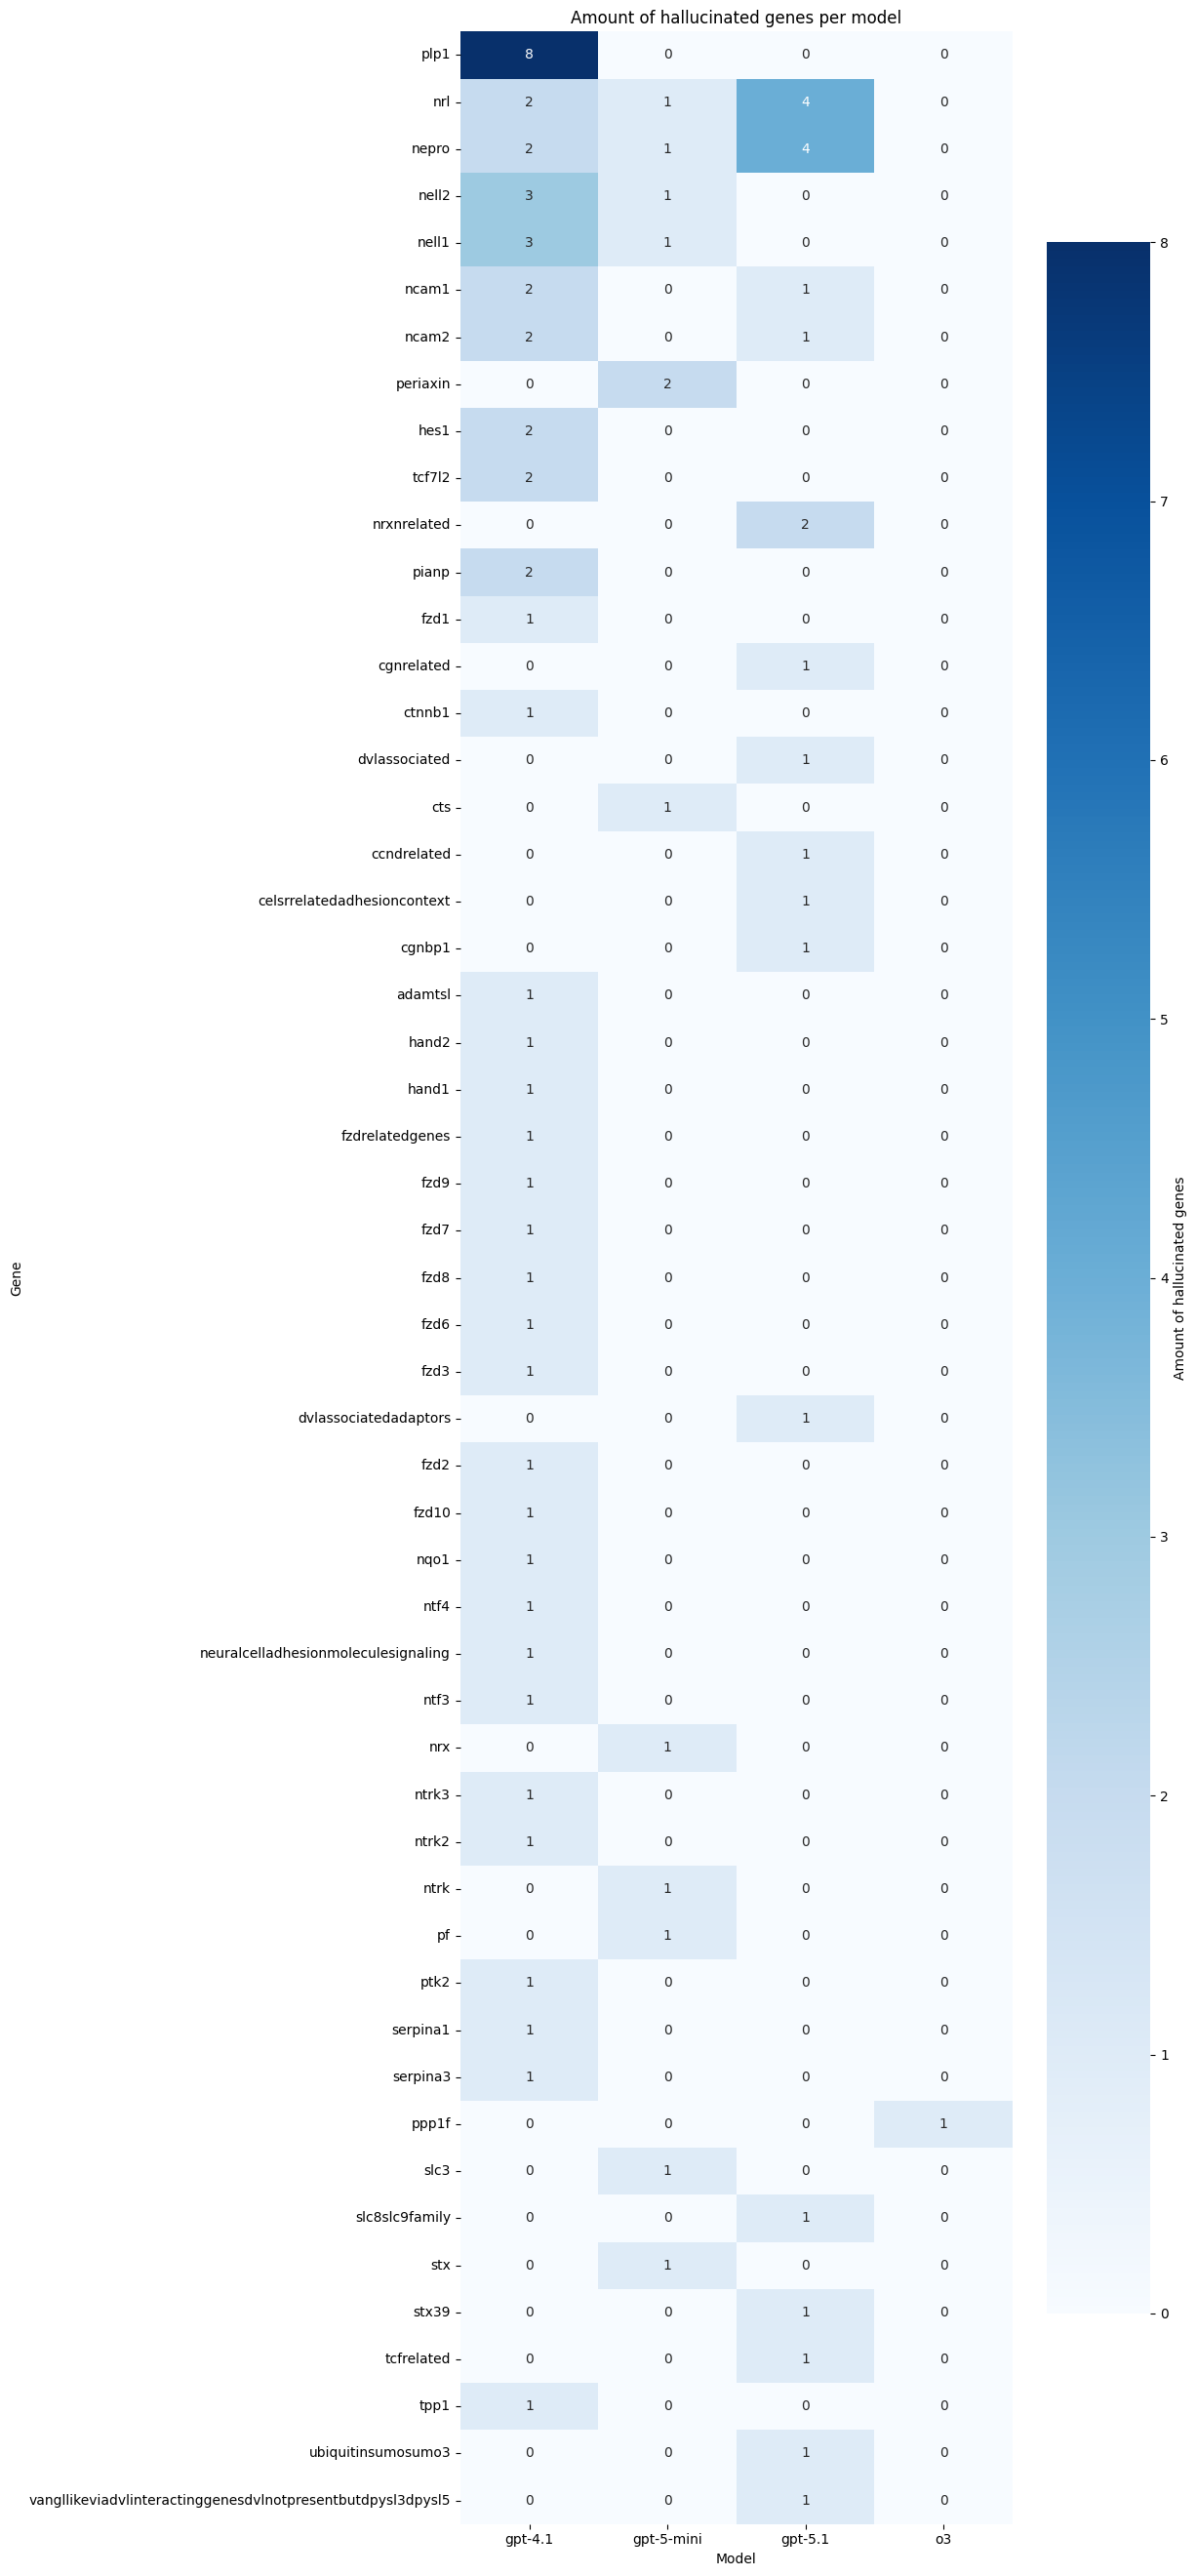

In [8]:
def ensure_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        import ast
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    return []

records = []
for model in df["generation_model"].unique():
    for genes in df[df["generation_model"]==model]["hallucinated_genes_list"].apply(ensure_list):
        for gene in genes:
            records.append({"generation_model": model, "gene": gene})

halluc_df = pd.DataFrame(records)

gene_counts = halluc_df.groupby(["gene", "generation_model"]).size().unstack(fill_value=0)

gene_counts["total"] = gene_counts.sum(axis=1)
gene_counts = gene_counts.sort_values("total", ascending=False)
gene_counts = gene_counts.drop(columns="total")  

plt.figure(figsize=(12, max(6, len(gene_counts)/2)))  
sns.heatmap(gene_counts, annot=True, cmap="Blues", cbar_kws={'label': 'Amount of hallucinated genes'})
plt.title("Amount of hallucinated genes per model")
plt.xlabel("Model")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


In [9]:
df["hallucinated_genes"] = df["hallucinated_genes_list"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) and len(x) > 0 else "None"
)

import plotly.express as px

fig = px.line(
    df,
    x="iteration",
    y="num_hallucinated_genes",
    color="generation_model",
    markers=True,
    hover_data={
        "hallucinated_genes": True,
        "num_hallucinated_genes": True
    }
)

fig.update_layout(
    title="Number of hallucinated genes per model across iterations",
    xaxis_title="Iteration",
    yaxis_title="Number of hallucinated genes"
)

fig.show()


In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

df["hallucinated_genes_list"] = df["hallucinated_genes_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

exploded = df[
    ["generation_model", "hallucinated_genes_list"]
].explode("hallucinated_genes_list")

exploded = exploded.dropna(subset=["hallucinated_genes_list"])

hallucinated_per_model = (
    exploded
    .groupby("generation_model")["hallucinated_genes_list"]
    .unique()
    .reset_index()
)

hallucinated_per_model.columns = [
    "generation_model",
    "hallucinated_genes"
]

hallucinated_per_model


,generation_model,hallucinated_genes
0,gpt-4.1,"[nrl, pianp, ncam2, serpina1, nell1, fzdrelatedgenes, serpina3, plp1, nqo1, ncam1, nepro, nell2, neuralcelladhesionmoleculesignaling, adamtsl, hes1, fzd10, tcf7l2, fzd9, fzd3, fzd7, fzd6, fzd8, fzd1, ctnnb1, fzd2, hand2, hand1, ntrk2, ntf4, ntrk3, tpp1, ptk2, ntf3]"
1,gpt-5-mini,"[stx, periaxin, nrl, nepro, nell1, nell2, ntrk, nrx, cts, slc3, pf]"
2,gpt-5.1,"[nrl, nepro, nrxnrelated, ccndrelated, dvlassociated, ubiquitinsumosumo3, cgnrelated, celsrrelatedadhesioncontext, slc8slc9family, dvlassociatedadaptors, ncam2, ncam1, tcfrelated, cgnbp1, vangllikeviadvlinteractinggenesdvlnotpresentbutdpysl3dpysl5, stx39]"
3,o3,[ppp1f]


### Mean hallucination percentage per model

In [11]:
halluc_perc = df.groupby("generation_model")["hallucination_perc_generation"].mean().reset_index()

print(halluc_perc)


  generation_model  hallucination_perc_generation
0          gpt-4.1                       3.317954
1       gpt-5-mini                       0.761566
2          gpt-5.1                       1.609252
3               o3                       0.128205
